# Hyperscale CapEx Analysis: Drivers, Category Allocation & Geographic Distribution

This notebook analyses the capital expenditure patterns of the five largest hyperscale cloud/AI infrastructure companies — **Amazon, Microsoft, Alphabet/Google, Meta, and Oracle** — covering:

1. **Historical capex trajectory** (2018–2026E) and the AI inflection point
2. **Key drivers** behind the unprecedented spending surge
3. **Category allocation** — servers/GPUs, power, construction, land, networking, cooling
4. **Geographic distribution** — where capex is being deployed globally
5. **Capital intensity** and financial sustainability implications
6. **CapEx vs backlog (RPO)** — tying spending to contracted demand

All results are also aggregated in the companion workbook: **`hyperscale_capex_analysis.xlsx`** (8 tabs).

---
*Data sourced from company earnings reports, analyst estimates, and industry research (Platformonomics, Epoch AI, MTN Consulting, AlixPartners). 2025E and 2026E figures are consensus estimates/company guidance as of Q1 2026.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
})

COLORS = {
    'Amazon': '#FF9900',
    'Microsoft': '#00A4EF',
    'Alphabet/Google': '#4285F4',
    'Meta': '#0668E1',
    'Oracle': '#F80000',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Data

In [2]:
capex_annual = pd.read_csv('data/hyperscale_capex_annual.csv')
capex_categories = pd.read_csv('data/capex_category_allocation.csv')
capex_geo = pd.read_csv('data/capex_geographic_allocation.csv')
capex_drivers = pd.read_csv('data/capex_drivers.csv')

print('=== Annual CapEx by Company ($B) ===')
display(capex_annual)
print(f'\n=== CapEx Category Allocation (2026E) ===')
display(capex_categories)
print(f'\n=== Geographic Allocation ===')
display(capex_geo[['Region', 'Pct_of_Total_2024', 'Pct_of_Total_2026E']])
print(f'\n=== Key CapEx Drivers ===')
display(capex_drivers[['Driver', 'Impact_Level', 'Category']])

=== Annual CapEx by Company ($B) ===


,Company,2018,2019,2020,2021,2022,2023,2024,2025E,2026E
0,Amazon,13.4,16.9,40.1,61.1,63.6,48.4,83.0,125.0,200.0
1,Microsoft,11.6,13.9,15.4,20.6,23.9,28.0,44.5,80.0,145.0
2,Alphabet/Google,25.1,23.5,22.3,24.6,31.5,32.3,52.5,91.4,180.0
3,Meta,13.7,15.1,15.1,19.2,31.4,28.1,39.2,72.2,125.0
4,Oracle,2.1,1.6,1.7,3.5,5.9,6.9,10.0,20.0,50.0



=== CapEx Category Allocation (2026E) ===


,Category,Pct_of_Total,Amount_2026E_Bn,Description
0,Servers & GPUs,35,242,GPU accelerators and server hardware (NVIDIA B...
1,Data Center Construction,18,124,Building shell structure interior fit-out and ...
2,Networking Equipment,8,55,Switches routers optical interconnects and fiber
3,Power Infrastructure,12,83,Electrical systems UPS generators switchgear t...
4,Cooling Systems,5,35,Liquid cooling CRAC units chillers and heat re...
5,Land Acquisition,3,21,Real estate acquisition and site development
6,Memory & Storage,7,48,HBM DDR5 SSDs and storage infrastructure
7,Other / Miscellaneous,12,83,Design engineering security systems software-d...



=== Geographic Allocation ===


,Region,Pct_of_Total_2024,Pct_of_Total_2026E
0,North America,50,48
1,Europe,22,20
2,Asia-Pacific,20,22
3,Middle East & Africa,4,5
4,Latin America,4,5



=== Key CapEx Drivers ===


,Driver,Impact_Level,Category
0,AI Model Training Demand,Very High,Demand
1,AI Inference Scale-Out,Very High,Demand
2,Cloud Revenue Growth,High,Demand
3,Enterprise AI Adoption,High,Demand
4,GPU Supply Constraints,Very High,Supply
5,Power Grid Bottlenecks,Very High,Infrastructure
6,Sovereign AI Requirements,Medium,Regulatory
7,Competitive Dynamics,High,Strategy
8,GPU Price Inflation,High,Cost
9,Interest Rate Environment,Medium,Financial


---
## 2. Historical CapEx Trajectory & the AI Inflection Point

Combined hyperscaler capex has **quadrupled** since GPT-4's release in March 2023. The 2024-2026 period represents the fastest capex growth rate in the history of the technology industry.

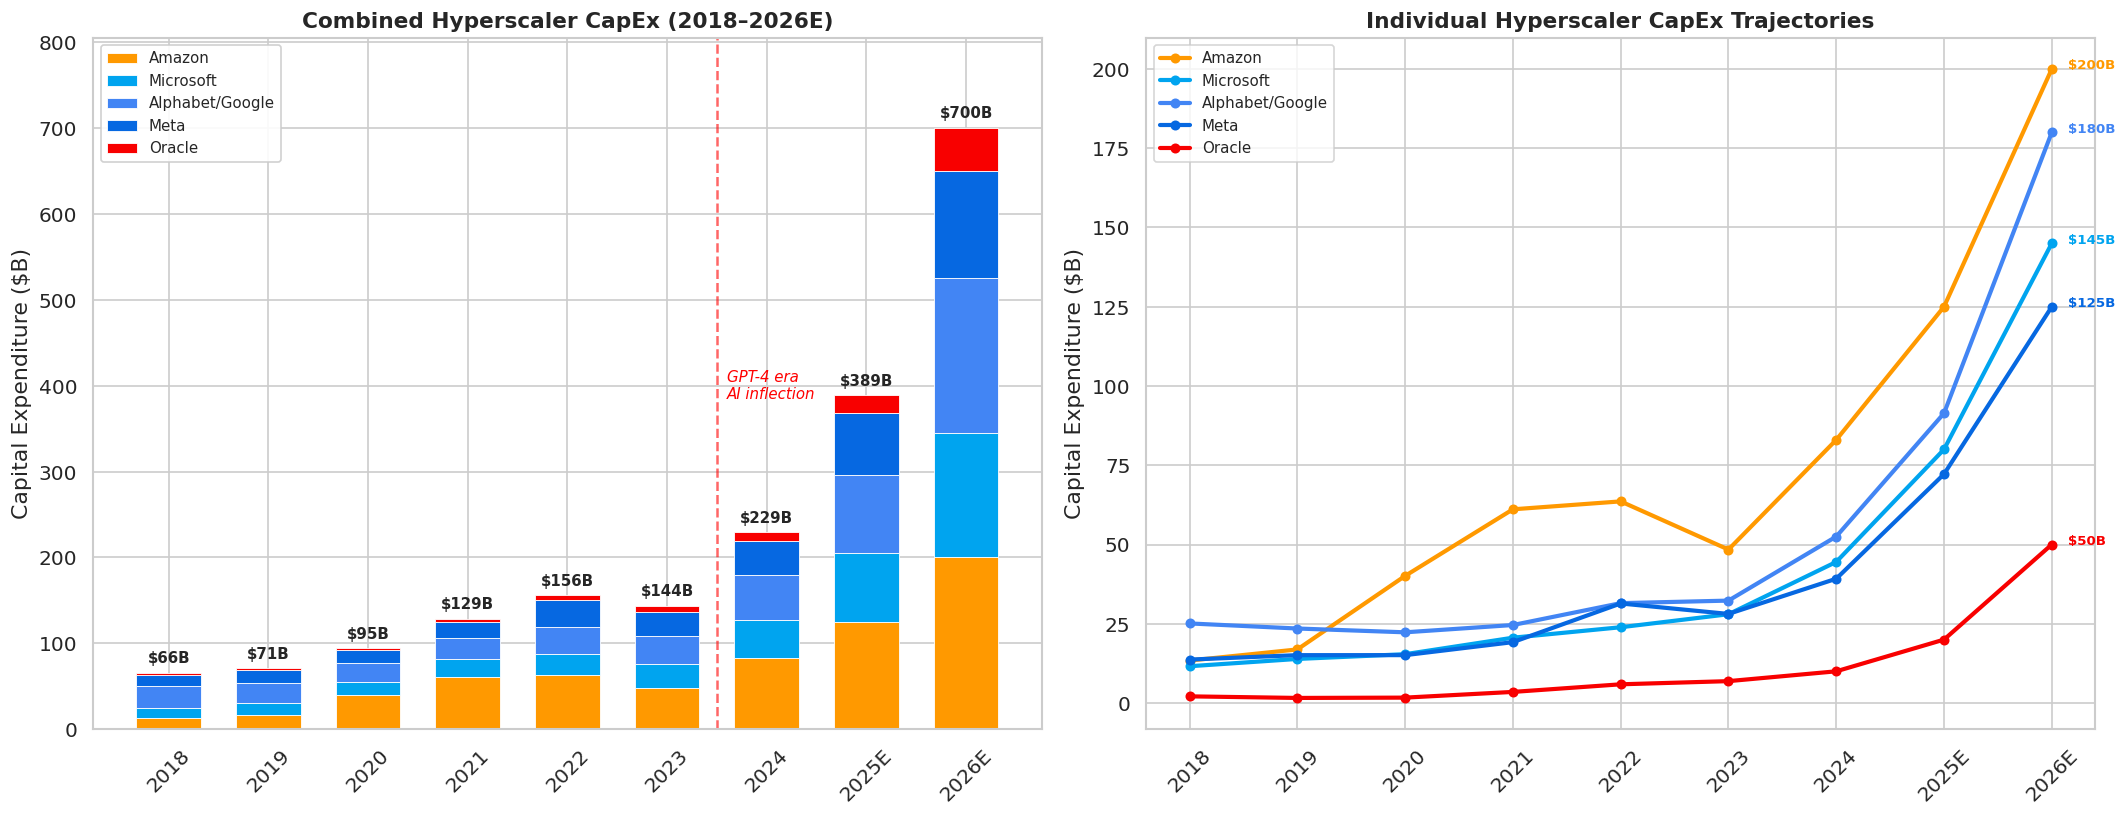


--- Year-over-Year Growth in Combined CapEx ---
  2018 → 2019: $66B → $71B  (+7.7%)
  2019 → 2020: $71B → $95B  (+33.2%)
  2020 → 2021: $95B → $129B  (+36.4%)
  2021 → 2022: $129B → $156B  (+21.2%)
  2022 → 2023: $156B → $144B  (-8.1%)
  2023 → 2024: $144B → $229B  (+59.5%)
  2024 → 2025E: $229B → $389B  (+69.5%)
  2025E → 2026E: $389B → $700B  (+80.1%)


In [3]:
years = [str(c) for c in capex_annual.columns if c != 'Company']
companies = capex_annual['Company'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left panel: stacked area chart ---
ax1 = axes[0]
x = range(len(years))
bottom = np.zeros(len(years))
for company in companies:
    vals = capex_annual[capex_annual['Company'] == company][years].values[0]
    ax1.bar(x, vals, bottom=bottom, label=company, color=COLORS.get(company, '#888'),
            width=0.65, edgecolor='white', linewidth=0.5)
    bottom += vals

totals = capex_annual[years].sum()
for i, total in enumerate(totals):
    ax1.text(i, total + 8, f'${total:.0f}B', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax1.axvline(x=years.index('2024') - 0.5, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
ax1.text(years.index('2024') - 0.4, max(totals) * 0.55, 'GPT-4 era\nAI inflection',
         color='red', fontsize=9, fontstyle='italic', ha='left')

ax1.set_xticks(x)
ax1.set_xticklabels(years, rotation=45)
ax1.set_ylabel('Capital Expenditure ($B)')
ax1.set_title('Combined Hyperscaler CapEx (2018–2026E)', fontweight='bold', fontsize=13)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.set_ylim(0, max(totals) * 1.15)

# --- Right panel: individual company growth ---
ax2 = axes[1]
for company in companies:
    vals = capex_annual[capex_annual['Company'] == company][years].values[0]
    ax2.plot(years, vals, marker='o', linewidth=2.5, markersize=5,
             label=company, color=COLORS.get(company, '#888'))
    ax2.annotate(f'${vals[-1]:.0f}B', xy=(years[-1], vals[-1]),
                 xytext=(10, 0), textcoords='offset points',
                 fontsize=8, fontweight='bold', color=COLORS.get(company, '#888'))

ax2.set_ylabel('Capital Expenditure ($B)')
ax2.set_title('Individual Hyperscaler CapEx Trajectories', fontweight='bold', fontsize=13)
ax2.legend(loc='upper left', fontsize=9)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/01_capex_historical_trajectory.png', bbox_inches='tight')
plt.show()

# Print growth statistics
print('\n--- Year-over-Year Growth in Combined CapEx ---')
for i in range(1, len(years)):
    prev_total = totals.iloc[i-1]
    curr_total = totals.iloc[i]
    growth = (curr_total / prev_total - 1) * 100
    print(f'  {years[i-1]} → {years[i]}: ${prev_total:.0f}B → ${curr_total:.0f}B  ({growth:+.1f}%)')

---
## 3. Key Drivers of Hyperscale CapEx

The capex surge is driven by a confluence of demand-side, supply-side, and structural factors. Below we categorise and rank them.

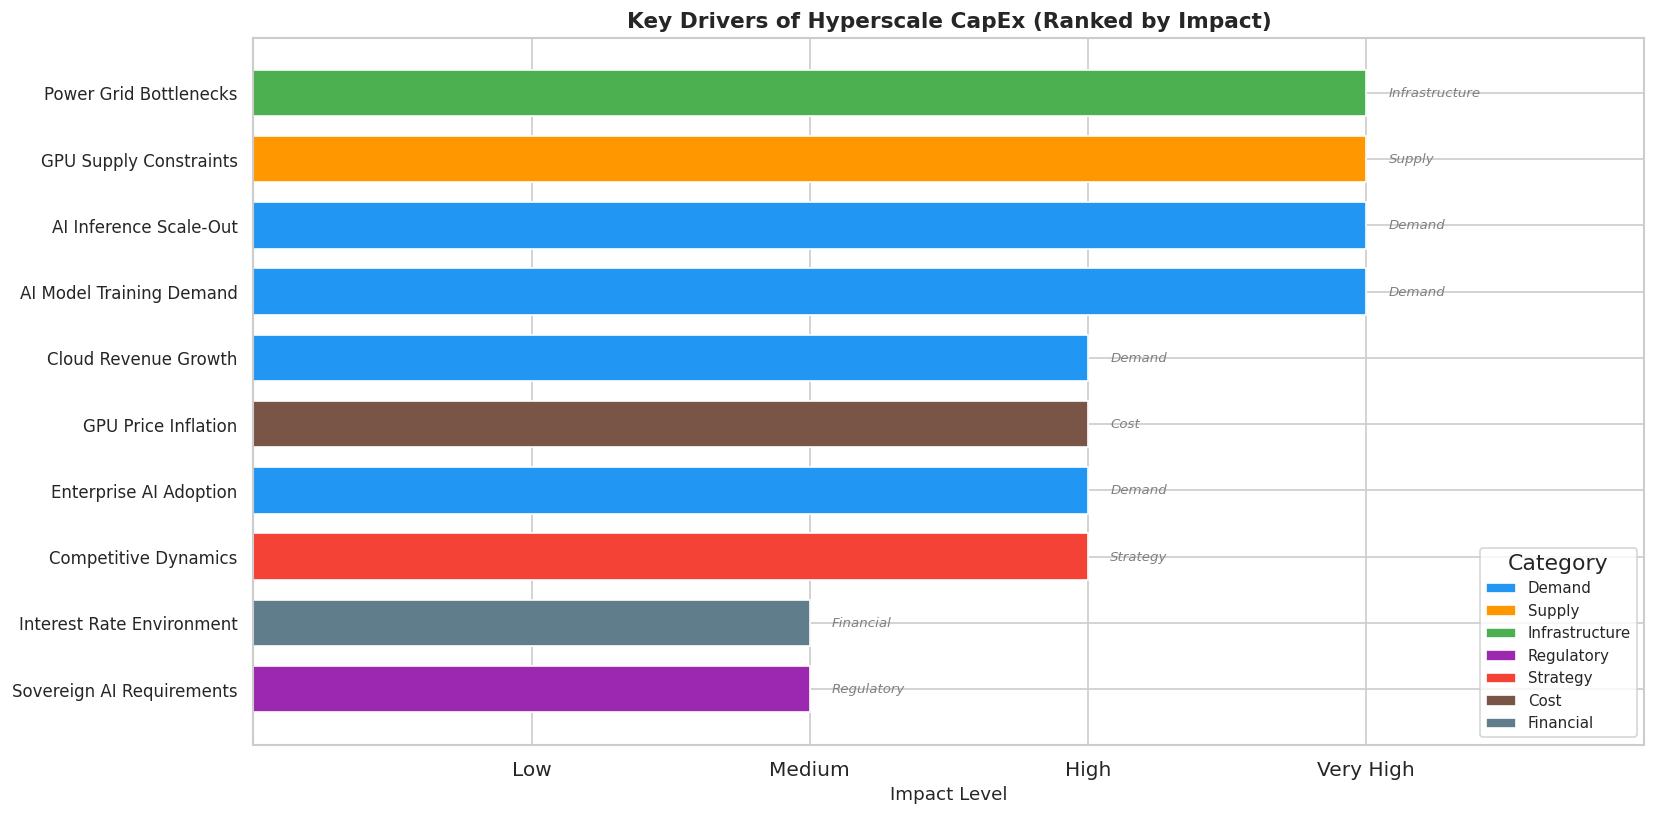


--- Driver Descriptions ---

  [Medium] Sovereign AI Requirements (Regulatory)
    Governments mandating in-country AI compute and data residency; driving geographic diversification of builds

  [Medium] Interest Rate Environment (Financial)
    Higher borrowing costs as hyperscalers issue $108B in bonds in 2025; $1.5T total debt issuance projected

  [High] Competitive Dynamics (Strategy)
    Arms race dynamics between hyperscalers; no company willing to under-invest and lose AI market position

  [High] Enterprise AI Adoption (Demand)
    Fortune 500 companies deploying private AI workloads on hyperscale platforms; Google Cloud backlog at $240B

  [High] GPU Price Inflation (Cost)
    Next-gen GPU systems (GB200 NVL72) cost $3M+ per rack; 15-25% hardware cost inflation

  [High] Cloud Revenue Growth (Demand)
    Cloud revenue growing 20-30% YoY across hyperscalers driving continued traditional infrastructure expansion

  [Very High] AI Model Training Demand (Demand)
    Exponential 

In [4]:
impact_order = {'Very High': 4, 'High': 3, 'Medium': 2, 'Low': 1}
drivers_sorted = capex_drivers.sort_values('Impact_Level',
    key=lambda s: s.map(impact_order), ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))

cat_colors = {'Demand': '#2196F3', 'Supply': '#FF9800', 'Infrastructure': '#4CAF50',
              'Regulatory': '#9C27B0', 'Strategy': '#F44336', 'Cost': '#795548',
              'Financial': '#607D8B'}
bar_colors = [cat_colors.get(c, '#888') for c in drivers_sorted['Category']]
impact_vals = drivers_sorted['Impact_Level'].map(impact_order).values

bars = ax.barh(range(len(drivers_sorted)), impact_vals, color=bar_colors,
               edgecolor='white', height=0.7)

ax.set_yticks(range(len(drivers_sorted)))
ax.set_yticklabels(drivers_sorted['Driver'], fontsize=10)
ax.set_xlabel('Impact Level', fontsize=11)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Low', 'Medium', 'High', 'Very High'])
ax.set_title('Key Drivers of Hyperscale CapEx (Ranked by Impact)', fontweight='bold', fontsize=13)
ax.set_xlim(0, 5)

for i, (idx, row) in enumerate(drivers_sorted.iterrows()):
    ax.text(impact_vals[i] + 0.08, i, row['Category'],
            va='center', fontsize=8, fontstyle='italic', color='gray')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()
                   if cat in drivers_sorted['Category'].values]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Category')

plt.tight_layout()
plt.savefig('data/02_capex_drivers.png', bbox_inches='tight')
plt.show()

print('\n--- Driver Descriptions ---')
for _, row in drivers_sorted.iterrows():
    print(f"\n  [{row['Impact_Level']}] {row['Driver']} ({row['Category']})")
    print(f"    {row['Description']}")

### Driver Analysis: Summary

**Demand-side drivers:**
- **AI training compute** requirements are growing ~4x annually. Models like GPT-5 and Gemini Ultra require clusters of 50,000–100,000+ GPUs running for months.
- **AI inference** is scaling even faster than training — every search query, copilot interaction, and agent action requires GPU compute.
- Enterprise cloud migration continues at 20–30% revenue growth rates, layering on top of AI demand.

**Supply-side constraints:**
- NVIDIA's Blackwell/Rubin GPUs are **sold out through 2027**. TSMC's advanced packaging (CoWoS) is the binding constraint.
- **Power infrastructure** is the most critical bottleneck: transformer lead times at 128 weeks, PJM capacity prices up 10x, and projects delayed 2–3 years.

**Strategic dynamics:**
- No hyperscaler is willing to under-invest and lose AI market position — creating an **arms race** dynamic.
- GPU and hardware cost inflation (15–25%) means the same capacity now costs significantly more.

---
## 4. CapEx Allocation by Category

How is the ~$700B in projected 2026 hyperscaler capex split across servers, power, construction, land, and other categories?

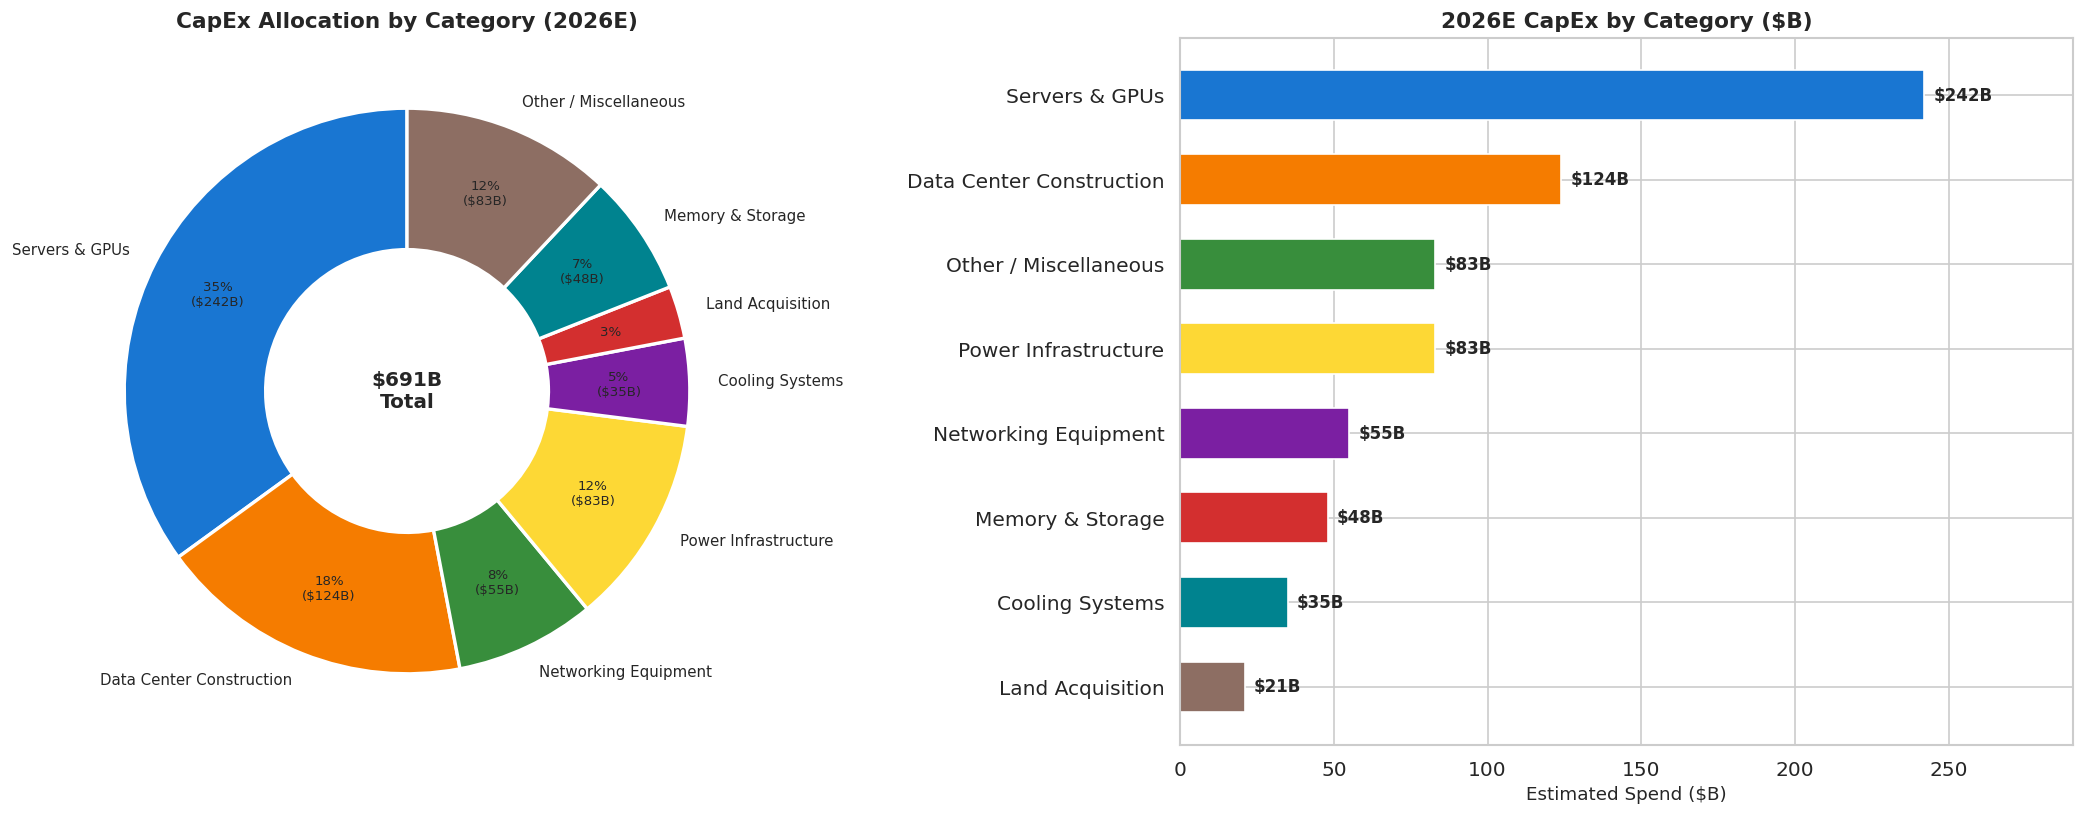


--- Category Breakdown Detail ---
Total 2026E CapEx: $691B

High-level split:
  IT Equipment (Servers, GPUs, Memory, Networking): $345B (50%)
  Facilities (Power, Construction, Cooling, Land): $263B (38%)
  Other: $83B (12%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: Pie / donut chart ---
ax1 = axes[0]
cat_palette = ['#1976D2', '#F57C00', '#388E3C', '#FDD835', '#7B1FA2',
               '#D32F2F', '#00838F', '#8D6E63']
wedges, texts, autotexts = ax1.pie(
    capex_categories['Pct_of_Total'],
    labels=capex_categories['Category'],
    autopct=lambda p: f'{p:.0f}%\n(${p*6.91:.0f}B)' if p > 4 else f'{p:.0f}%',
    colors=cat_palette,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
)
for t in autotexts:
    t.set_fontsize(8)
for t in texts:
    t.set_fontsize(9)
ax1.set_title('CapEx Allocation by Category (2026E)', fontweight='bold', fontsize=13)
centre_circle = plt.Circle((0, 0), 0.35, fc='white')
ax1.add_artist(centre_circle)
ax1.text(0, 0, '$691B\nTotal', ha='center', va='center', fontsize=12, fontweight='bold')

# --- Right: horizontal bar chart with $ amounts ---
ax2 = axes[1]
cats_sorted = capex_categories.sort_values('Amount_2026E_Bn', ascending=True)
bars = ax2.barh(cats_sorted['Category'], cats_sorted['Amount_2026E_Bn'],
                color=cat_palette[:len(cats_sorted)][::-1], edgecolor='white', height=0.6)
for bar, val in zip(bars, cats_sorted['Amount_2026E_Bn']):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'${val}B', va='center', fontsize=10, fontweight='bold')

ax2.set_xlabel('Estimated Spend ($B)', fontsize=11)
ax2.set_title('2026E CapEx by Category ($B)', fontweight='bold', fontsize=13)
ax2.set_xlim(0, max(cats_sorted['Amount_2026E_Bn']) * 1.2)

plt.tight_layout()
plt.savefig('data/03_capex_category_allocation.png', bbox_inches='tight')
plt.show()

print('\n--- Category Breakdown Detail ---')
total_capex = capex_categories['Amount_2026E_Bn'].sum()
print(f'Total 2026E CapEx: ${total_capex}B\n')

it_vs_facility = pd.DataFrame({
    'Bucket': ['IT Equipment\n(Servers, GPUs, Memory, Networking)', 'Facilities\n(Power, Construction, Cooling, Land)', 'Other'],
    'Amount': [
        capex_categories[capex_categories['Category'].isin(['Servers & GPUs', 'Networking Equipment', 'Memory & Storage'])]['Amount_2026E_Bn'].sum(),
        capex_categories[capex_categories['Category'].isin(['Data Center Construction', 'Power Infrastructure', 'Cooling Systems', 'Land Acquisition'])]['Amount_2026E_Bn'].sum(),
        capex_categories[capex_categories['Category'].isin(['Other / Miscellaneous'])]['Amount_2026E_Bn'].sum()
    ]
})
print('High-level split:')
for _, row in it_vs_facility.iterrows():
    pct = row['Amount'] / total_capex * 100
    print(f"  {row['Bucket'].replace(chr(10), ' ')}: ${row['Amount']}B ({pct:.0f}%)")

### Category Analysis: Key Takeaways

**Servers & GPUs dominate** at ~35% of total capex (~$242B). NVIDIA captures ~90% of the GPU/accelerator market. A single GB200 NVL72 rack costs $3M+, and hyperscalers are ordering hundreds of thousands of GPUs.

**Facilities (power + construction + cooling + land)** account for ~38% of total capex (~$263B):
- **Power infrastructure** (12%, ~$83B) is now the fastest-growing category due to massive electrical systems requirements and utility-scale power procurement.
- **Construction** (18%, ~$124B) covers the building shells, structural work, and site preparation for new data centers.
- **Cooling** (5%, ~$35B) is increasingly shifting to liquid cooling for high-density GPU racks (50–120 kW per rack vs. 10–15 kW for traditional servers).
- **Land** (3%, ~$21B) is relatively small but critical — sites with access to power, fiber, and water command premium prices.

**Google's CFO guidance** provides a useful benchmark: roughly **60% to servers** (TPUs, GPUs, CPUs) and **40% to data centers and networking**. This broadly aligns with our category-level estimates.

---
## 5. Geographic Distribution of CapEx

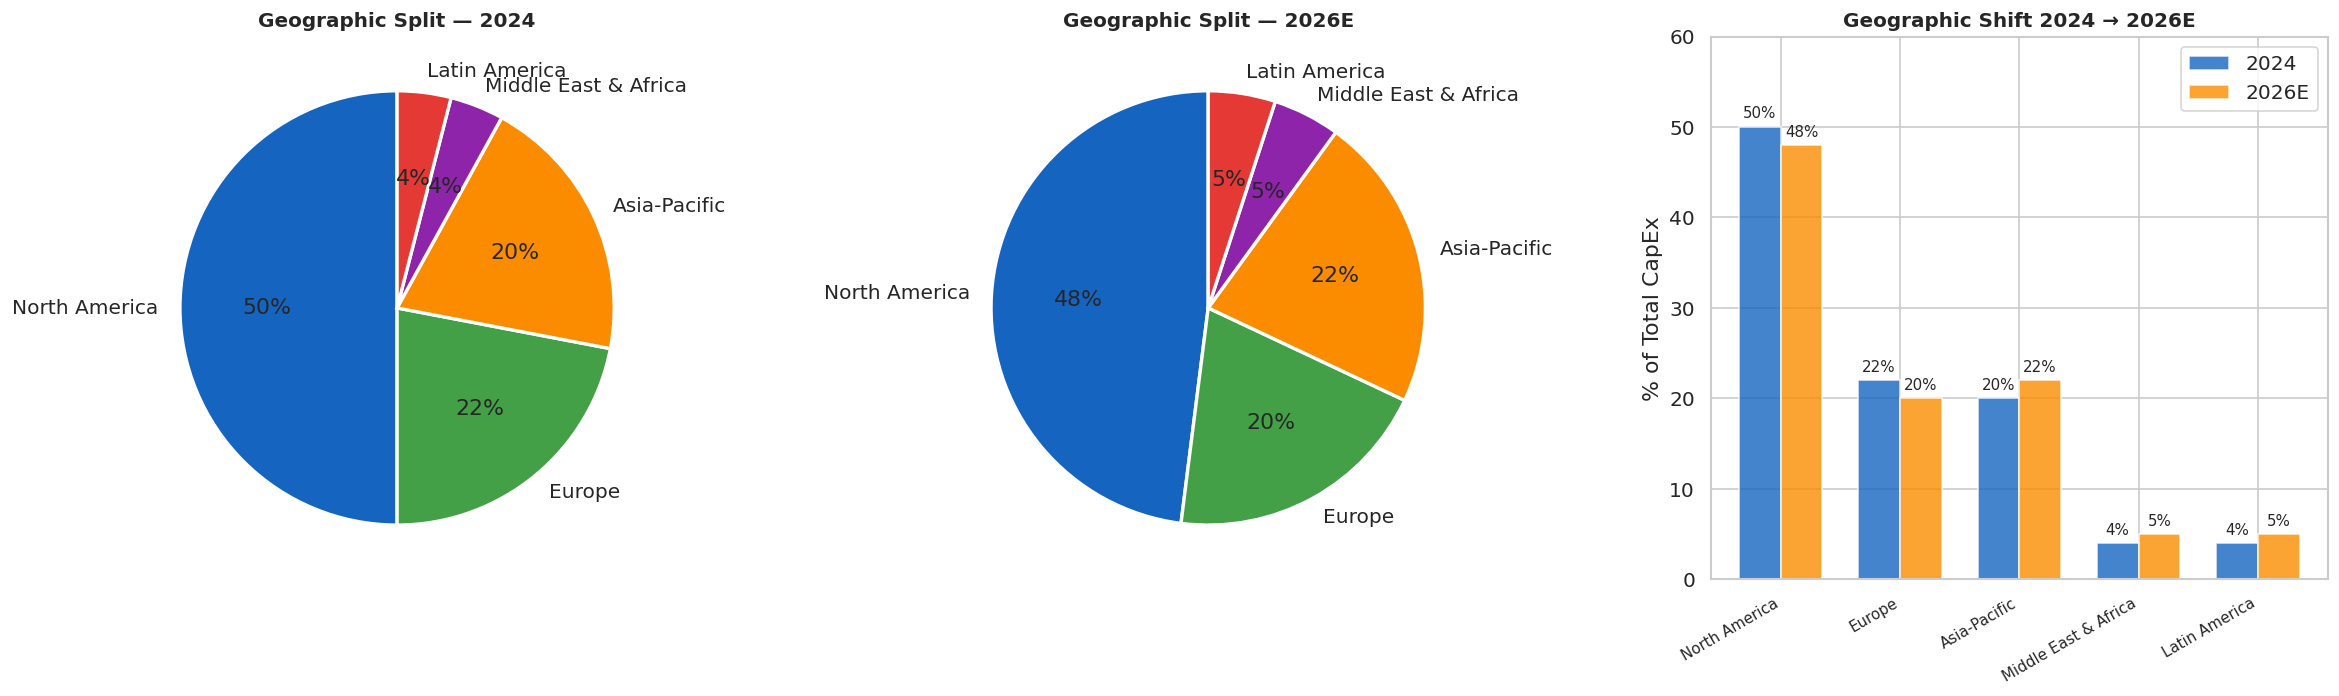


--- Geographic Allocation Detail ---
  North America            :  48% (~$332B)  ↓ 2pp vs 2024  |  Key: US (Virginia Ohio Texas Oregon Georgia) Canada
  Europe                   :  20% (~$138B)  ↓ 2pp vs 2024  |  Key: Ireland Netherlands UK Denmark Sweden Germany
  Asia-Pacific             :  22% (~$152B)  ↑ 2pp vs 2024  |  Key: Singapore Japan Australia India South Korea Malaysia Indonesia
  Middle East & Africa     :   5% (~$35B)  ↑ 1pp vs 2024  |  Key: UAE Saudi Arabia South Africa Israel
  Latin America            :   5% (~$35B)  ↑ 1pp vs 2024  |  Key: Brazil Mexico Chile Colombia


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

geo_colors = ['#1565C0', '#43A047', '#FB8C00', '#8E24AA', '#E53935']

# --- Left: 2024 pie ---
ax1 = axes[0]
ax1.pie(capex_geo['Pct_of_Total_2024'], labels=capex_geo['Region'],
        autopct='%1.0f%%', colors=geo_colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax1.set_title('Geographic Split — 2024', fontweight='bold', fontsize=12)

# --- Middle: 2026E pie ---
ax2 = axes[1]
ax2.pie(capex_geo['Pct_of_Total_2026E'], labels=capex_geo['Region'],
        autopct='%1.0f%%', colors=geo_colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Geographic Split — 2026E', fontweight='bold', fontsize=12)

# --- Right: grouped bar showing shift ---
ax3 = axes[2]
x = np.arange(len(capex_geo))
width = 0.35
bars1 = ax3.bar(x - width/2, capex_geo['Pct_of_Total_2024'], width,
                label='2024', color='#1565C0', alpha=0.8)
bars2 = ax3.bar(x + width/2, capex_geo['Pct_of_Total_2026E'], width,
                label='2026E', color='#FB8C00', alpha=0.8)

ax3.set_xticks(x)
ax3.set_xticklabels(capex_geo['Region'], rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('% of Total CapEx')
ax3.set_title('Geographic Shift 2024 → 2026E', fontweight='bold', fontsize=12)
ax3.legend()
ax3.set_ylim(0, 60)

for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.0f}%', ha='center', fontsize=9)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/04_capex_geographic_distribution.png', bbox_inches='tight')
plt.show()

print('\n--- Geographic Allocation Detail ---')
total_2026 = 691
for _, row in capex_geo.iterrows():
    est_spend = total_2026 * row['Pct_of_Total_2026E'] / 100
    shift = row['Pct_of_Total_2026E'] - row['Pct_of_Total_2024']
    direction = '↑' if shift > 0 else ('↓' if shift < 0 else '→')
    print(f"  {row['Region']:25s}: {row['Pct_of_Total_2026E']:3.0f}% (~${est_spend:.0f}B)  "
          f"{direction} {abs(shift):.0f}pp vs 2024  |  Key: {row['Key_Markets']}")

### Geographic Analysis: Key Takeaways

**North America remains dominant** at ~48% of total capex (~$332B in 2026E), but its share is declining slightly as hyperscalers diversify globally:
- **Virginia (NOVA)** remains the world's largest data center market, but power constraints are pushing expansion to Ohio, Texas, Oregon, and Georgia.
- Microsoft's new East US 3 region in Atlanta exemplifies this geographic diversification within the US.

**Asia-Pacific is gaining share** (20% → 22%), driven by:
- Strong cloud adoption in Japan, Australia, India, South Korea
- Emerging markets: Malaysia, Indonesia becoming hyperscale hubs
- Chinese hyperscalers (Alibaba, Tencent, ByteDance) expanding in Southeast Asia

**Europe remains significant** (~20%, ~$138B) but faces regulatory and power headwinds:
- Ireland and Netherlands are maturing, pushing expansion to Nordics (Denmark, Sweden)
- Sovereign AI mandates in France, Germany driving local builds
- Nuclear-linked data center projects being explored

**Emerging regions (MEA, LatAm)** are growing from a small base (~10% combined), driven by:
- UAE/Saudi sovereign AI ambitions and Stargate-adjacent projects
- AWS's announced $5B Mexico region, expansion in Brazil

**Power availability is the primary geographic determinant** — sites are increasingly chosen based on access to reliable, low-cost electricity rather than proximity to end users.

---
## 6. Capital Intensity & Market Share Dynamics

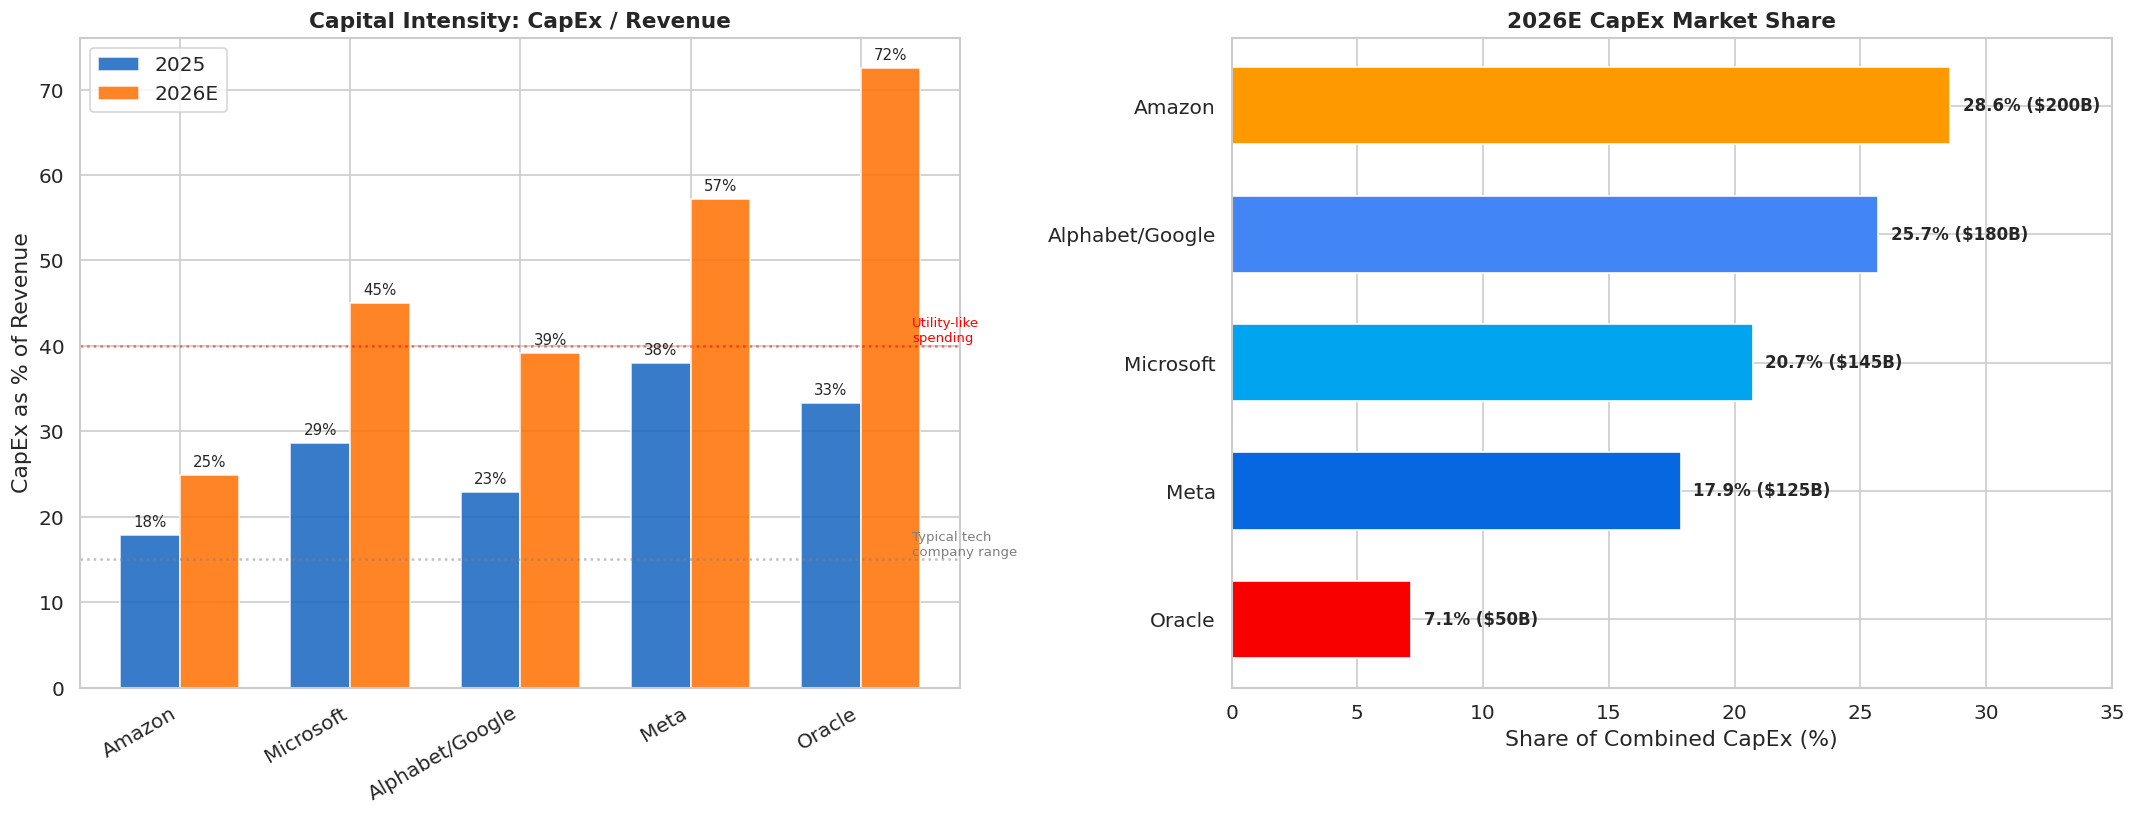


--- Capital Intensity Summary ---
  Amazon            : 2025=18%  2026E=25%  (CapEx: $125B → $200B)
  Microsoft         : 2025=29%  2026E=45%  (CapEx: $80B → $145B)
  Alphabet/Google   : 2025=23%  2026E=39%  (CapEx: $91B → $180B)
  Meta              : 2025=38%  2026E=57%  (CapEx: $72B → $125B)
  Oracle            : 2025=33%  2026E=72%  (CapEx: $20B → $50B)


In [7]:
revenue_2025 = {'Amazon': 700, 'Microsoft': 280, 'Alphabet/Google': 400, 'Meta': 190, 'Oracle': 60}
capex_2025 = dict(zip(capex_annual['Company'], capex_annual['2025E']))
capex_2026 = dict(zip(capex_annual['Company'], capex_annual['2026E']))

intensity_df = pd.DataFrame({
    'Company': list(revenue_2025.keys()),
    'Revenue_2025': list(revenue_2025.values()),
    'CapEx_2025': [capex_2025[c] for c in revenue_2025.keys()],
    'CapEx_2026E': [capex_2026[c] for c in revenue_2025.keys()],
})
intensity_df['Intensity_2025'] = intensity_df['CapEx_2025'] / intensity_df['Revenue_2025'] * 100
intensity_df['Intensity_2026E'] = intensity_df['CapEx_2026E'] / (intensity_df['Revenue_2025'] * 1.15) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: capital intensity comparison ---
ax1 = axes[0]
x = np.arange(len(intensity_df))
width = 0.35
ax1.bar(x - width/2, intensity_df['Intensity_2025'], width, label='2025',
        color='#1565C0', alpha=0.85)
ax1.bar(x + width/2, intensity_df['Intensity_2026E'], width, label='2026E',
        color='#FF6F00', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(intensity_df['Company'], rotation=30, ha='right')
ax1.set_ylabel('CapEx as % of Revenue')
ax1.set_title('Capital Intensity: CapEx / Revenue', fontweight='bold', fontsize=13)
ax1.legend()
ax1.axhline(y=15, color='gray', linestyle=':', alpha=0.5)
ax1.text(4.3, 15.5, 'Typical tech\ncompany range', fontsize=8, color='gray')
ax1.axhline(y=40, color='red', linestyle=':', alpha=0.5)
ax1.text(4.3, 40.5, 'Utility-like\nspending', fontsize=8, color='red')

for i, row in intensity_df.iterrows():
    ax1.text(i - width/2, row['Intensity_2025'] + 1, f"{row['Intensity_2025']:.0f}%",
             ha='center', fontsize=9)
    ax1.text(i + width/2, row['Intensity_2026E'] + 1, f"{row['Intensity_2026E']:.0f}%",
             ha='center', fontsize=9)

# --- Right: capex market share ---
ax2 = axes[1]
total_2026 = sum(capex_2026.values())
shares = {c: v/total_2026*100 for c, v in capex_2026.items()}
share_df = pd.DataFrame(list(shares.items()), columns=['Company', 'Share'])
share_df = share_df.sort_values('Share', ascending=True)

bars = ax2.barh(share_df['Company'], share_df['Share'],
                color=[COLORS.get(c, '#888') for c in share_df['Company']],
                edgecolor='white', height=0.6)
for bar, val in zip(bars, share_df['Share']):
    spend = val / 100 * total_2026
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}% (${spend:.0f}B)', va='center', fontsize=10, fontweight='bold')

ax2.set_xlabel('Share of Combined CapEx (%)')
ax2.set_title('2026E CapEx Market Share', fontweight='bold', fontsize=13)
ax2.set_xlim(0, 35)

plt.tight_layout()
plt.savefig('data/05_capital_intensity_market_share.png', bbox_inches='tight')
plt.show()

print('\n--- Capital Intensity Summary ---')
for _, row in intensity_df.iterrows():
    print(f"  {row['Company']:18s}: 2025={row['Intensity_2025']:.0f}%  2026E={row['Intensity_2026E']:.0f}%  "
          f"(CapEx: ${row['CapEx_2025']:.0f}B → ${row['CapEx_2026E']:.0f}B)")

---
## 7. The Power Constraint: The Binding Bottleneck

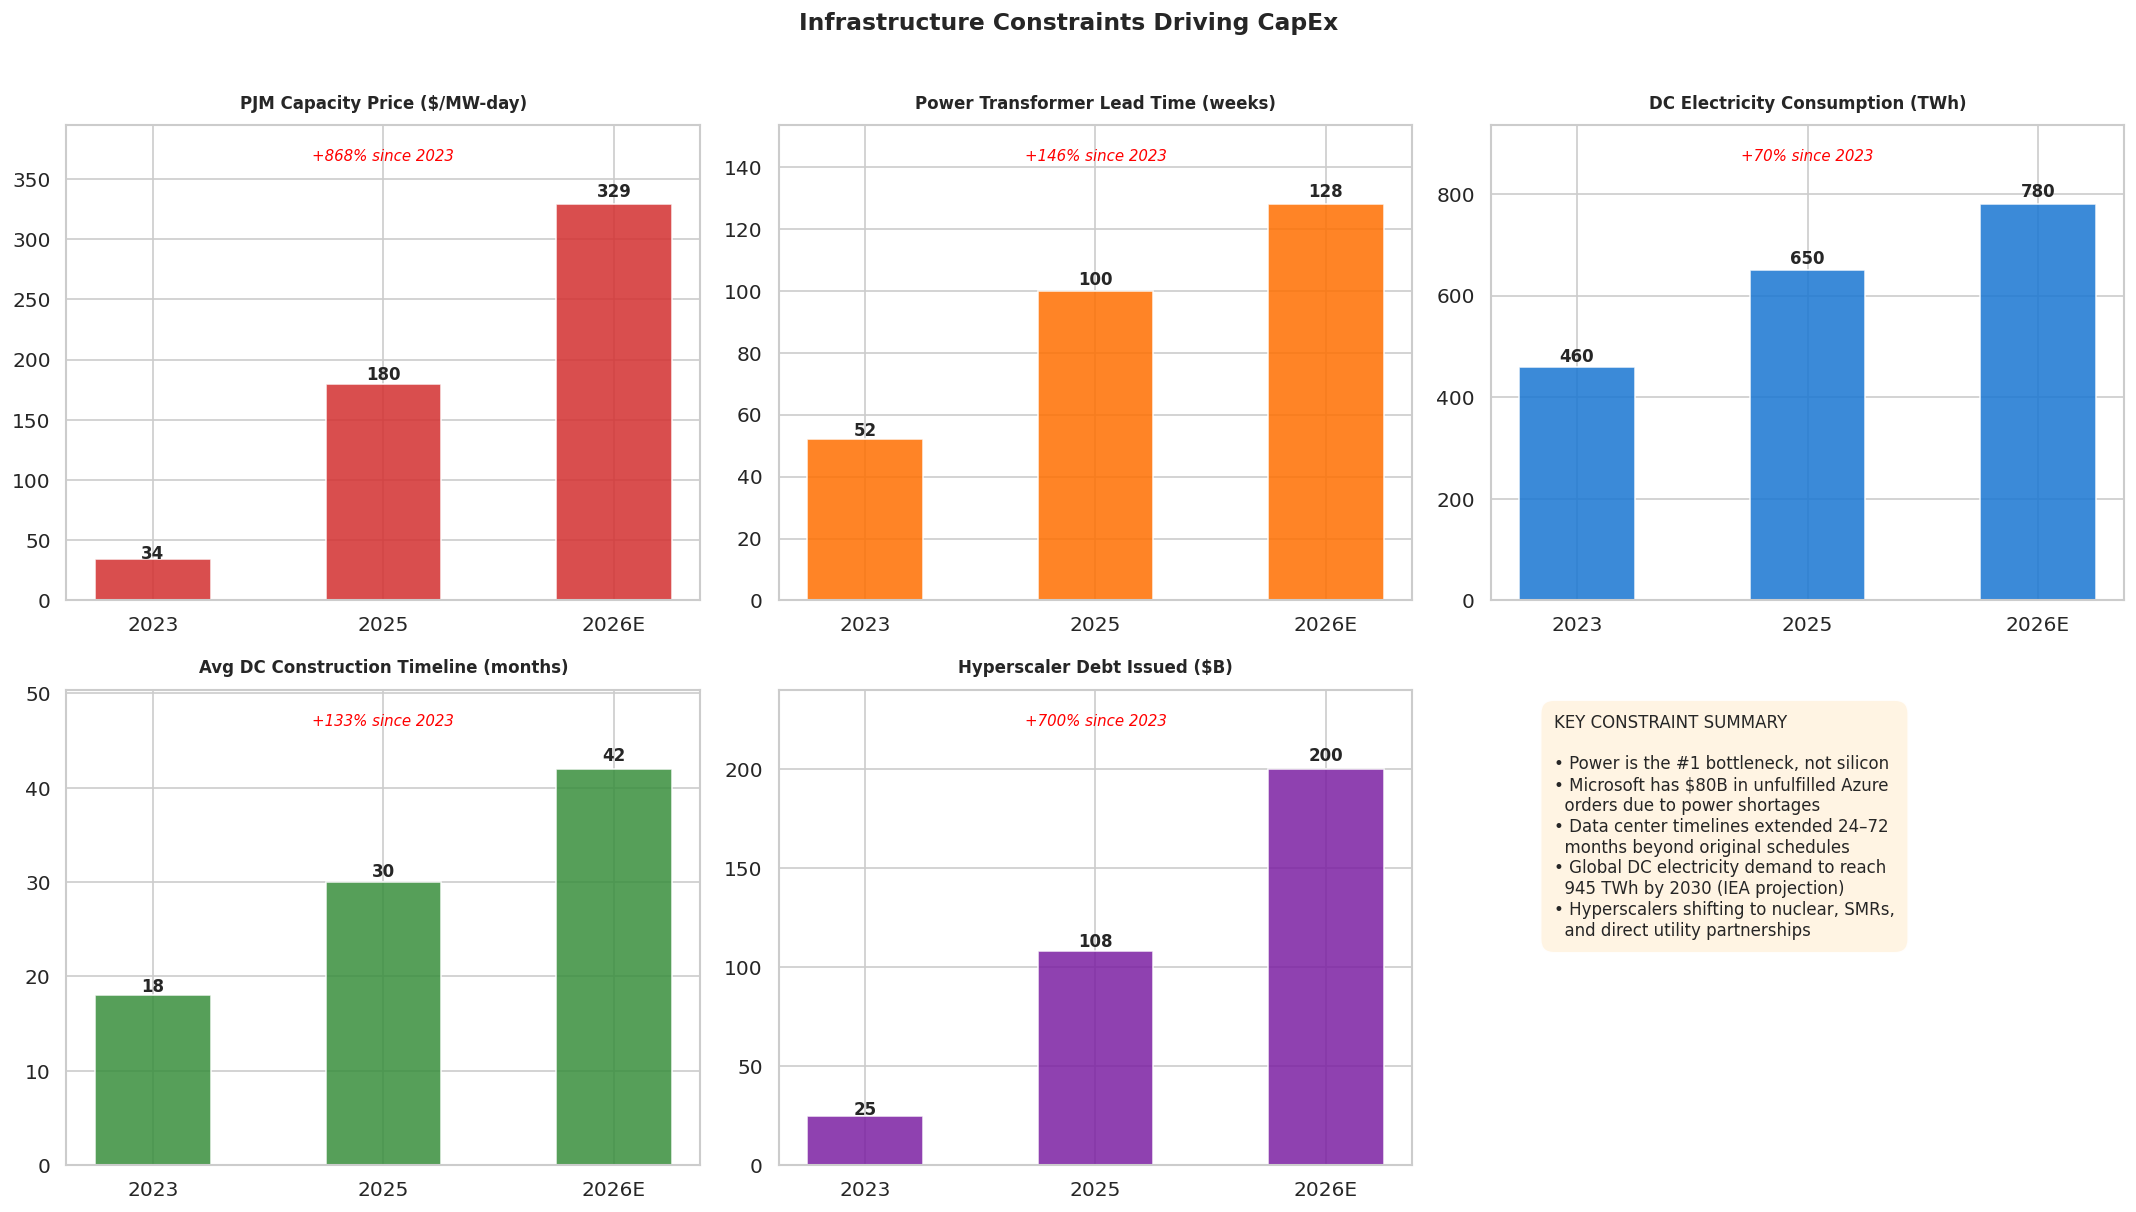

In [8]:
power_data = pd.DataFrame({
    'Metric': [
        'PJM Capacity Price ($/MW-day)',
        'Power Transformer Lead Time (weeks)',
        'DC Electricity Consumption (TWh)',
        'Avg DC Construction Timeline (months)',
        'Hyperscaler Debt Issued ($B)',
    ],
    '2023': [34, 52, 460, 18, 25],
    '2025': [180, 100, 650, 30, 108],
    '2026E': [329, 128, 780, 42, 200],
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

bar_colors_list = ['#D32F2F', '#FF6F00', '#1976D2', '#388E3C', '#7B1FA2']

for i, (_, row) in enumerate(power_data.iterrows()):
    ax = axes[i]
    vals = [row['2023'], row['2025'], row['2026E']]
    years_pw = ['2023', '2025', '2026E']
    bars = ax.bar(years_pw, vals, color=bar_colors_list[i], alpha=0.85,
                  edgecolor='white', width=0.5)
    ax.set_title(row['Metric'], fontweight='bold', fontsize=10, pad=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2)
    growth = (vals[-1] / vals[0] - 1) * 100
    ax.text(0.5, 0.95, f'+{growth:.0f}% since 2023',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9, color='red', fontstyle='italic')

axes[5].axis('off')
summary_text = (
    'KEY CONSTRAINT SUMMARY\n\n'
    '• Power is the #1 bottleneck, not silicon\n'
    '• Microsoft has $80B in unfulfilled Azure\n'
    '  orders due to power shortages\n'
    '• Data center timelines extended 24–72\n'
    '  months beyond original schedules\n'
    '• Global DC electricity demand to reach\n'
    '  945 TWh by 2030 (IEA projection)\n'
    '• Hyperscalers shifting to nuclear, SMRs,\n'
    '  and direct utility partnerships'
)
axes[5].text(0.1, 0.95, summary_text, transform=axes[5].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF3E0', alpha=0.9))

fig.suptitle('Infrastructure Constraints Driving CapEx', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/06_power_constraints.png', bbox_inches='tight')
plt.show()

---
## 8. CapEx vs Backlog (RPO): Is Spending Justified by Demand?

Remaining Performance Obligations (RPO) represent contracted future revenue not yet recognised. Comparing RPO to capex assesses whether hyperscalers are building ahead of, or in line with, demand.

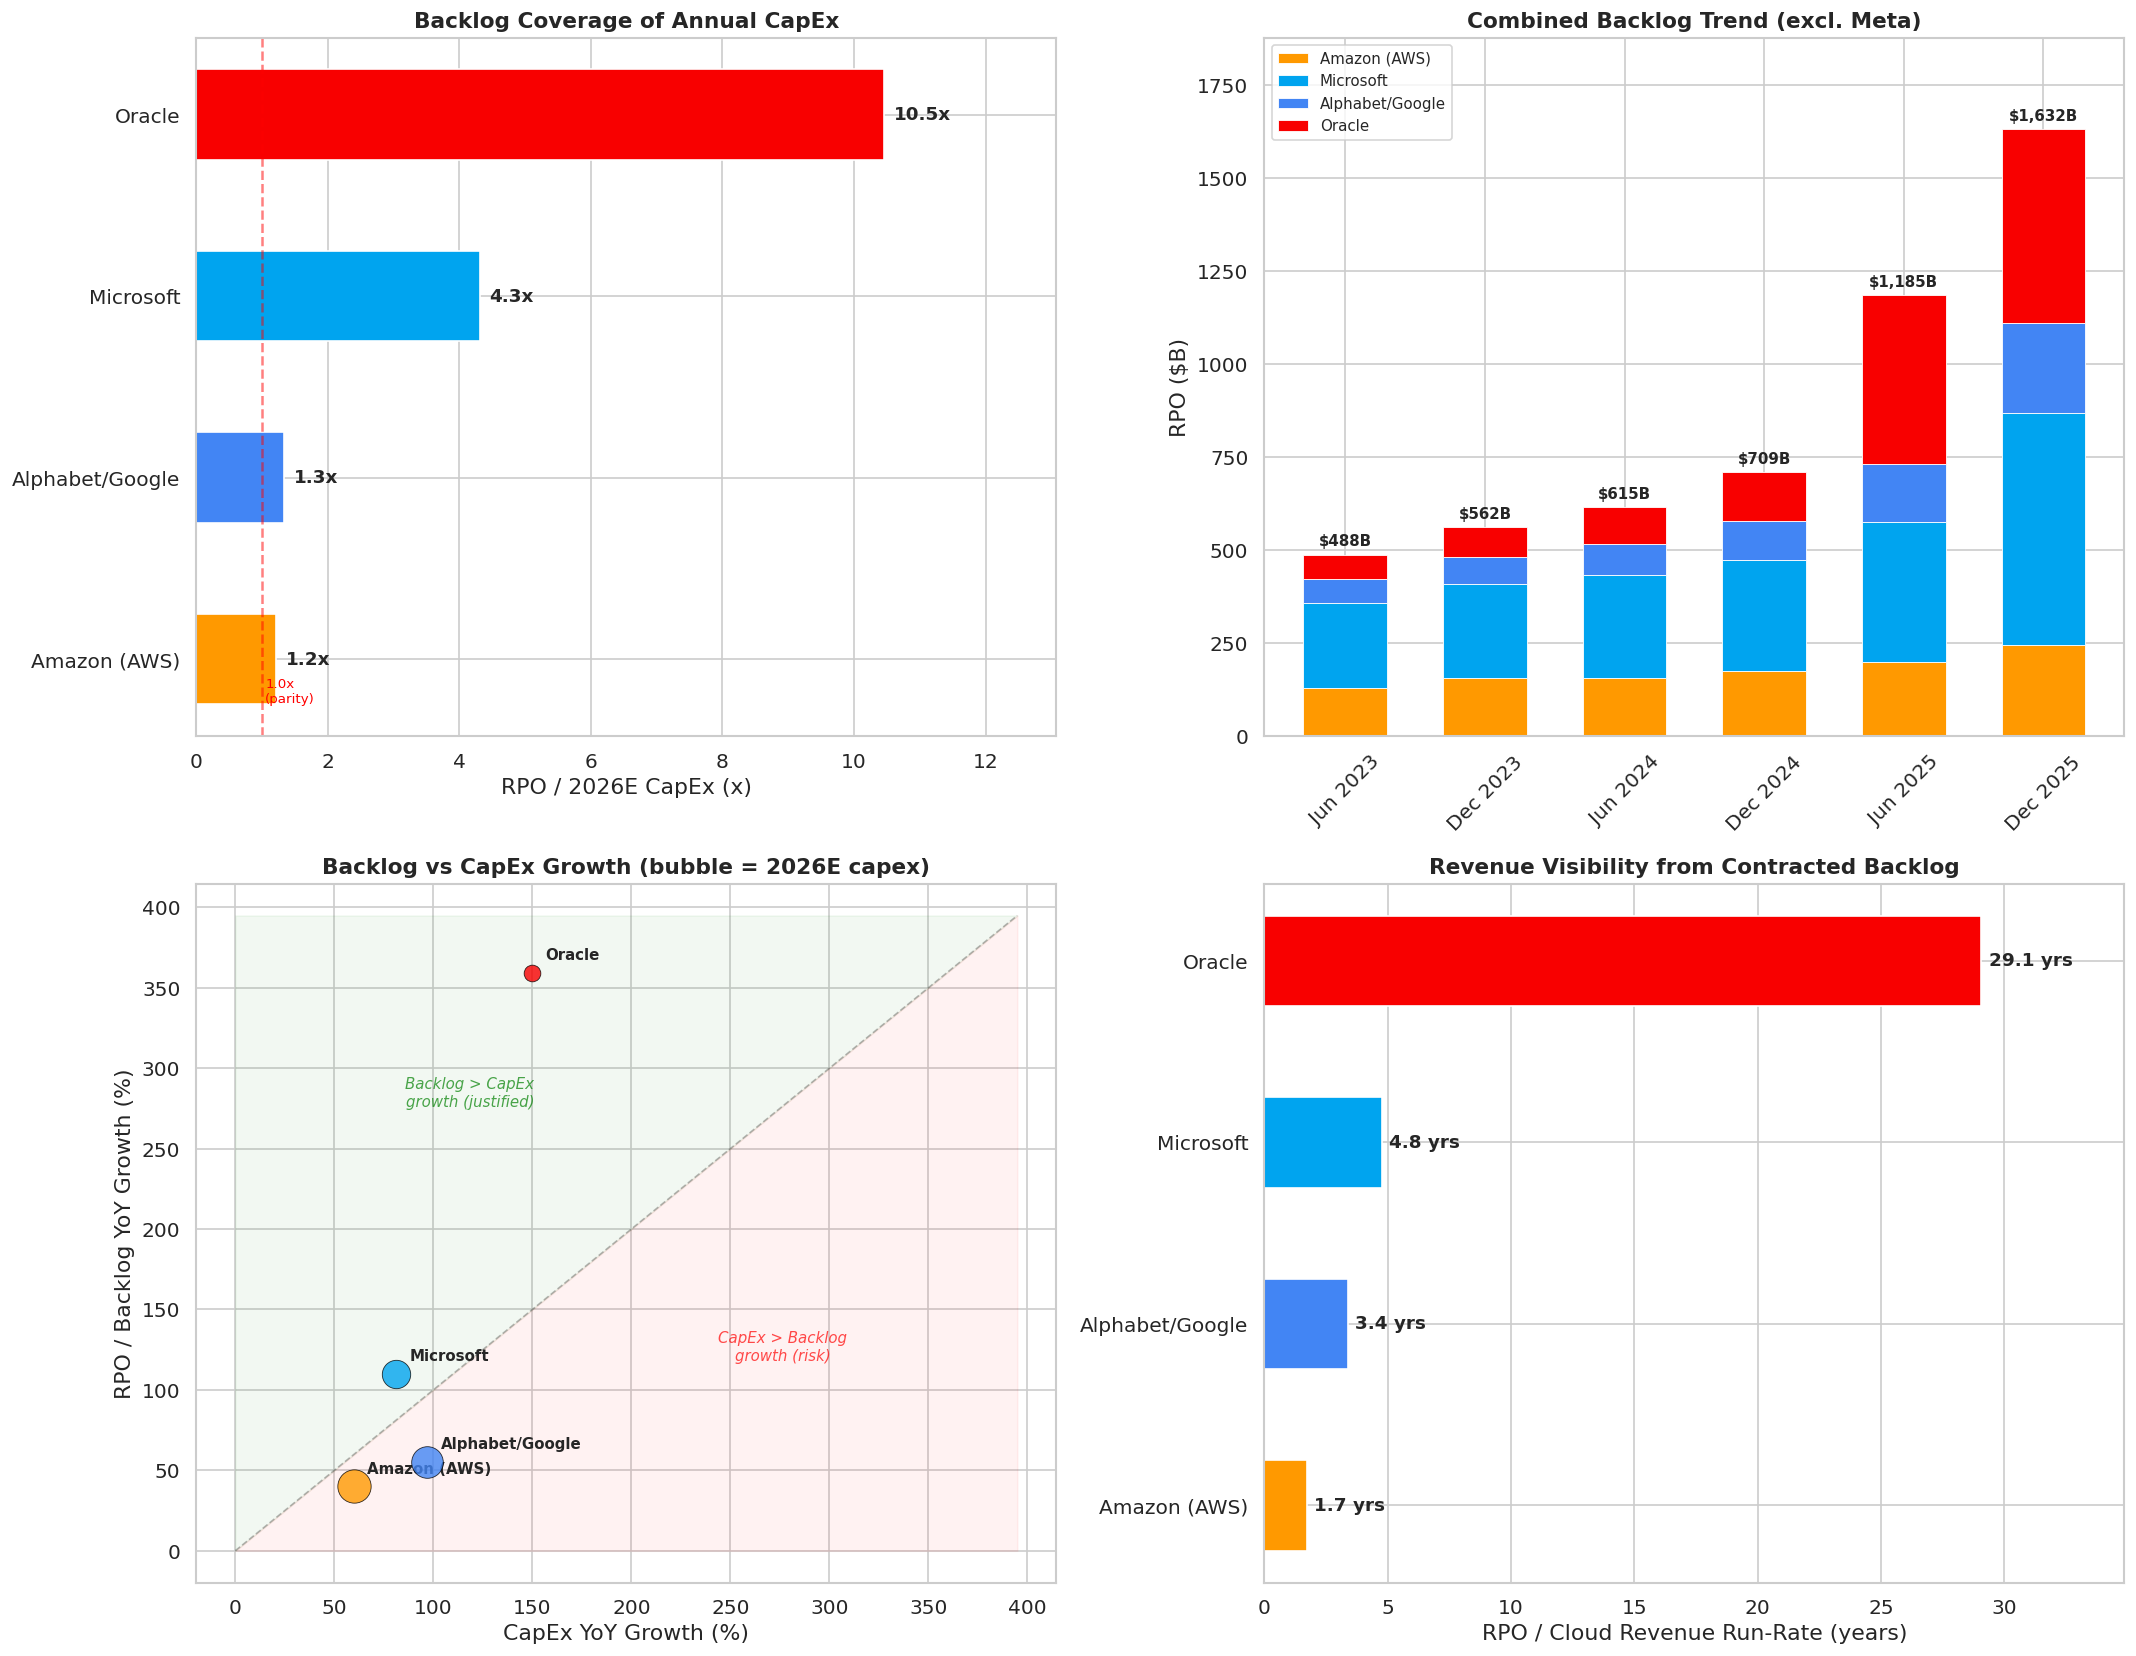


=== CapEx vs Backlog Tie-Out ===

Company                RPO ($B)   2026E CX   RPO/CX  RPO/Rev   BL YoY   CX YoY Signal
--------------------------------------------------------------------------------------------------------------
Amazon (AWS)               $244 $     200     1.2x    1.7yr      40%      60%   Building ahead of demand — RPO growing but capex faster
Microsoft                  $625 $     145     4.3x    4.8yr     110%      81%   Strong demand justification — 4.3x coverage (45% = OpenAI)
Alphabet/Google            $240 $     180     1.3x    3.4yr      55%      97%   Balanced build — 1.3x coverage, AI backlog accelerating
Oracle                     $523 $      50    10.5x   29.1yr     359%     150%   Severely supply-constrained — 10.5x coverage, must build faster
Meta                        N/A $     125      N/A      N/A      N/A      73%   Internal AI — no external RPO; capex for Llama/Reels/ads infra


In [9]:
rpo_data = pd.DataFrame({
    'Company': ['Amazon (AWS)', 'Microsoft', 'Alphabet/Google', 'Oracle', 'Meta'],
    'Latest_RPO_Bn': [244, 625, 240, 523, np.nan],
    'RPO_Period': ['Q4 2025', 'FQ2 2026', 'Q4 2025', 'FQ2 2026', 'N/A'],
    'RPO_YoY_Growth': [0.40, 1.10, 0.55, 3.59, np.nan],
    'CapEx_2025_Bn': [125, 80, 91.4, 20, 72.2],
    'CapEx_2026E_Bn': [200, 145, 180, 50, 125],
    'Cloud_Rev_RunRate_Bn': [142, 131, 71, 18, np.nan],
})

rpo_data['RPO_to_CapEx'] = rpo_data['Latest_RPO_Bn'] / rpo_data['CapEx_2026E_Bn']
rpo_data['RPO_to_Revenue'] = rpo_data['Latest_RPO_Bn'] / rpo_data['Cloud_Rev_RunRate_Bn']
rpo_data['CapEx_YoY'] = rpo_data['CapEx_2026E_Bn'] / rpo_data['CapEx_2025_Bn'] - 1

# ── Historical RPO trend ────────────────────────────────────────────
rpo_trend = pd.DataFrame({
    'Period': ['Jun 2023', 'Dec 2023', 'Jun 2024', 'Dec 2024', 'Jun 2025', 'Dec 2025'],
    'Amazon (AWS)': [130, 155, 157, 175, 200, 244],
    'Microsoft': [229, 253, 275, 298, 375, 625],
    'Alphabet/Google': [64, 74, 84, 106, 155, 240],
    'Oracle': [65, 80, 99, 130, 455, 523],
})
rpo_trend['Combined'] = rpo_trend[['Amazon (AWS)', 'Microsoft', 'Alphabet/Google', 'Oracle']].sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ── Panel 1: RPO / CapEx ratio bar chart ─────────────────────────
ax1 = axes[0, 0]
mask = rpo_data['Latest_RPO_Bn'].notna()
rpo_plot = rpo_data[mask].sort_values('RPO_to_CapEx', ascending=True)
colors_rpo = ['#FF9900', '#00A4EF', '#4285F4', '#F80000']
bar_colors = [colors_rpo[['Amazon (AWS)', 'Microsoft', 'Alphabet/Google', 'Oracle'].index(c)]
              for c in rpo_plot['Company']]
bars = ax1.barh(rpo_plot['Company'], rpo_plot['RPO_to_CapEx'], color=bar_colors,
                edgecolor='white', height=0.5)
for bar, val in zip(bars, rpo_plot['RPO_to_CapEx']):
    ax1.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}x', va='center', fontsize=11, fontweight='bold')
ax1.set_xlabel('RPO / 2026E CapEx (x)')
ax1.set_title('Backlog Coverage of Annual CapEx', fontweight='bold', fontsize=13)
ax1.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.text(1.05, -0.1, '1.0x\n(parity)', color='red', fontsize=8, va='top')
ax1.set_xlim(0, max(rpo_plot['RPO_to_CapEx']) * 1.25)

# ── Panel 2: stacked RPO trend ───────────────────────────────────
ax2 = axes[0, 1]
x_pos = range(len(rpo_trend))
companies_rpo = ['Amazon (AWS)', 'Microsoft', 'Alphabet/Google', 'Oracle']
bottom = np.zeros(len(rpo_trend))
for i, c in enumerate(companies_rpo):
    vals = rpo_trend[c].values
    ax2.bar(x_pos, vals, bottom=bottom, label=c, color=colors_rpo[i],
            width=0.6, edgecolor='white', linewidth=0.5)
    bottom += vals

for i, total in enumerate(rpo_trend['Combined']):
    ax2.text(i, total + 15, f'${total:,.0f}B', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(rpo_trend['Period'], rotation=45)
ax2.set_ylabel('RPO ($B)')
ax2.set_title('Combined Backlog Trend (excl. Meta)', fontweight='bold', fontsize=13)
ax2.legend(fontsize=9, loc='upper left')
ax2.set_ylim(0, max(rpo_trend['Combined']) * 1.15)

# ── Panel 3: backlog growth vs capex growth scatter ──────────────
ax3 = axes[1, 0]
scatter_data = rpo_data[mask].copy()
for _, row in scatter_data.iterrows():
    c = row['Company']
    color = colors_rpo[companies_rpo.index(c)]
    ax3.scatter(row['CapEx_YoY'] * 100, row['RPO_YoY_Growth'] * 100,
                s=row['CapEx_2026E_Bn'] * 2, color=color, alpha=0.8,
                edgecolors='black', linewidth=0.5, zorder=5)
    ax3.annotate(c, (row['CapEx_YoY'] * 100, row['RPO_YoY_Growth'] * 100),
                 xytext=(8, 8), textcoords='offset points', fontsize=9, fontweight='bold')

lim = max(scatter_data['RPO_YoY_Growth'].max() * 100, scatter_data['CapEx_YoY'].max() * 100) * 1.1
ax3.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1)
ax3.fill_between([0, lim], [0, lim], [lim, lim], alpha=0.05, color='green')
ax3.fill_between([0, lim], [0, 0], [0, lim], alpha=0.05, color='red')
ax3.text(lim * 0.7, lim * 0.3, 'CapEx > Backlog\ngrowth (risk)', fontsize=9,
         color='red', fontstyle='italic', ha='center', alpha=0.7)
ax3.text(lim * 0.3, lim * 0.7, 'Backlog > CapEx\ngrowth (justified)', fontsize=9,
         color='green', fontstyle='italic', ha='center', alpha=0.7)
ax3.set_xlabel('CapEx YoY Growth (%)')
ax3.set_ylabel('RPO / Backlog YoY Growth (%)')
ax3.set_title('Backlog vs CapEx Growth (bubble = 2026E capex)', fontweight='bold', fontsize=13)

# ── Panel 4: RPO / Revenue (years of visibility) ────────────────
ax4 = axes[1, 1]
vis_data = rpo_data[mask].sort_values('RPO_to_Revenue', ascending=True)
bar_colors2 = [colors_rpo[companies_rpo.index(c)] for c in vis_data['Company']]
bars = ax4.barh(vis_data['Company'], vis_data['RPO_to_Revenue'], color=bar_colors2,
                edgecolor='white', height=0.5)
for bar, val in zip(bars, vis_data['RPO_to_Revenue']):
    ax4.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} yrs', va='center', fontsize=11, fontweight='bold')
ax4.set_xlabel('RPO / Cloud Revenue Run-Rate (years)')
ax4.set_title('Revenue Visibility from Contracted Backlog', fontweight='bold', fontsize=13)
ax4.set_xlim(0, max(vis_data['RPO_to_Revenue']) * 1.2)

plt.tight_layout()
plt.savefig('data/08_capex_vs_backlog.png', bbox_inches='tight')
plt.show()

# Print tie-out table
print('\n=== CapEx vs Backlog Tie-Out ===\n')
print(f"{'Company':<20} {'RPO ($B)':>10} {'2026E CX':>10} {'RPO/CX':>8} {'RPO/Rev':>8} "
      f"{'BL YoY':>8} {'CX YoY':>8} {'Signal'}")
print('-' * 110)
signals = {
    'Amazon (AWS)': 'Building ahead of demand — RPO growing but capex faster',
    'Microsoft': 'Strong demand justification — 4.3x coverage (45% = OpenAI)',
    'Alphabet/Google': 'Balanced build — 1.3x coverage, AI backlog accelerating',
    'Oracle': 'Severely supply-constrained — 10.5x coverage, must build faster',
    'Meta': 'Internal AI — no external RPO; capex for Llama/Reels/ads infra',
}
for _, row in rpo_data.iterrows():
    rpo_str = f"${row['Latest_RPO_Bn']:.0f}" if pd.notna(row['Latest_RPO_Bn']) else 'N/A'
    r2c = f"{row['RPO_to_CapEx']:.1f}x" if pd.notna(row['RPO_to_CapEx']) else 'N/A'
    r2r = f"{row['RPO_to_Revenue']:.1f}yr" if pd.notna(row['RPO_to_Revenue']) else 'N/A'
    byoy = f"{row['RPO_YoY_Growth']:.0%}" if pd.notna(row['RPO_YoY_Growth']) else 'N/A'
    cxyoy = f"{row['CapEx_YoY']:.0%}"
    print(f"{row['Company']:<20} {rpo_str:>10} ${row['CapEx_2026E_Bn']:>8.0f} {r2c:>8} "
          f"{r2r:>8} {byoy:>8} {cxyoy:>8}   {signals[row['Company']]}")

### CapEx vs Backlog: Key Takeaways

**The combined hyperscaler backlog (RPO) stands at ~$1.6 trillion** across AWS, Microsoft, Google, and Oracle — providing **2.3x coverage** of their combined 2026E capex. This broadly supports the thesis that spending is demand-justified, not speculative.

| Company | RPO/CapEx | Signal |
|---------|-----------|--------|
| **Oracle** | 10.5x | Massively supply-constrained; RPO ($523B) dwarfs capex ($50B). Needs to build far faster. |
| **Microsoft** | 4.3x | Strongest demand justification among the Big Three. 45% of backlog attributable to OpenAI. |
| **Alphabet/Google** | 1.3x | Balanced build. AI-driven backlog accelerating (+55% YoY). |
| **Amazon (AWS)** | 1.2x | Backlog growing (+40% YoY) but capex growing faster (+60% YoY) — building ahead of contracted demand. Management argues supply-constrained. |
| **Meta** | N/A | No external cloud business; capex is driven entirely by internal AI infrastructure needs (Llama training, Reels, ads ranking). Cannot be evaluated via RPO. |

**Backlog growth vs capex growth** is the most telling signal:
- **Microsoft** and **Oracle** have backlog growth significantly exceeding capex growth — demand is outrunning supply.
- **Amazon** has capex growth outpacing backlog growth — building speculatively, though management argues this reflects supply constraints limiting what can be contracted.
- **Google** is roughly balanced.

All results are aggregated in the companion spreadsheet: **`hyperscale_capex_analysis.xlsx`** (see "CapEx vs Backlog" tab for full tie-out with interpretation guide).

---
## 9. Summary & Investment Implications

### Key Findings

| Dimension | Key Insight |
|-----------|------------|
| **Scale** | Combined hyperscaler capex to reach ~$700B in 2026, up from $66B in 2018 — a **10x increase in 8 years** |
| **Primary Driver** | AI infrastructure (training + inference) accounts for **~75% of total capex** |
| **Category Split** | Servers/GPUs (~35%), Facilities (power + construction + cooling + land, ~38%), Networking + Memory + Other (~27%) |
| **Geographic** | North America ~48%, Europe ~20%, APAC ~22%, MEA + LatAm ~10% — diversifying due to power constraints |
| **Binding Constraint** | **Power availability**, not GPU supply, is the primary bottleneck limiting deployment speed |
| **Capital Intensity** | Hyperscalers now spend 30–70% of revenue on capex, resembling utilities more than tech companies |
| **Financial Strain** | Free cash flow under severe pressure; $108B in bonds issued in 2025, projecting $1.5T in total debt needed |

### Supply Chain Beneficiaries

The capex surge creates a multi-hundred-billion-dollar opportunity across the supply chain:

- **Semiconductors**: NVIDIA (GPUs), Broadcom (custom ASICs, networking), AMD (GPUs, CPUs), Marvell (networking)
- **Memory**: SK Hynix (HBM leader), Samsung, Micron
- **Power**: Eaton, Vertiv, Schneider Electric (UPS/PDUs), GE Vernova (transformers)
- **Cooling**: Vertiv, Modine Manufacturing (liquid cooling)
- **Construction/REITs**: Equinix, Digital Realty, QTS, CyrusOne
- **Utilities**: Constellation Energy, Vistra (nuclear PPAs)

### Risks to Monitor

1. **AI revenue monetisation** — can hyperscalers generate sufficient returns to justify $700B/yr in capex?
2. **Power timeline risk** — delays in grid infrastructure could strand capital in idle facilities
3. **Interest rate sensitivity** — rising borrowing costs on $1.5T in projected debt issuance
4. **Technology transition** — next-gen architectures (e.g. more efficient inference chips) could reduce capex needs
5. **Regulatory risk** — ESG/environmental pushback on data center energy consumption

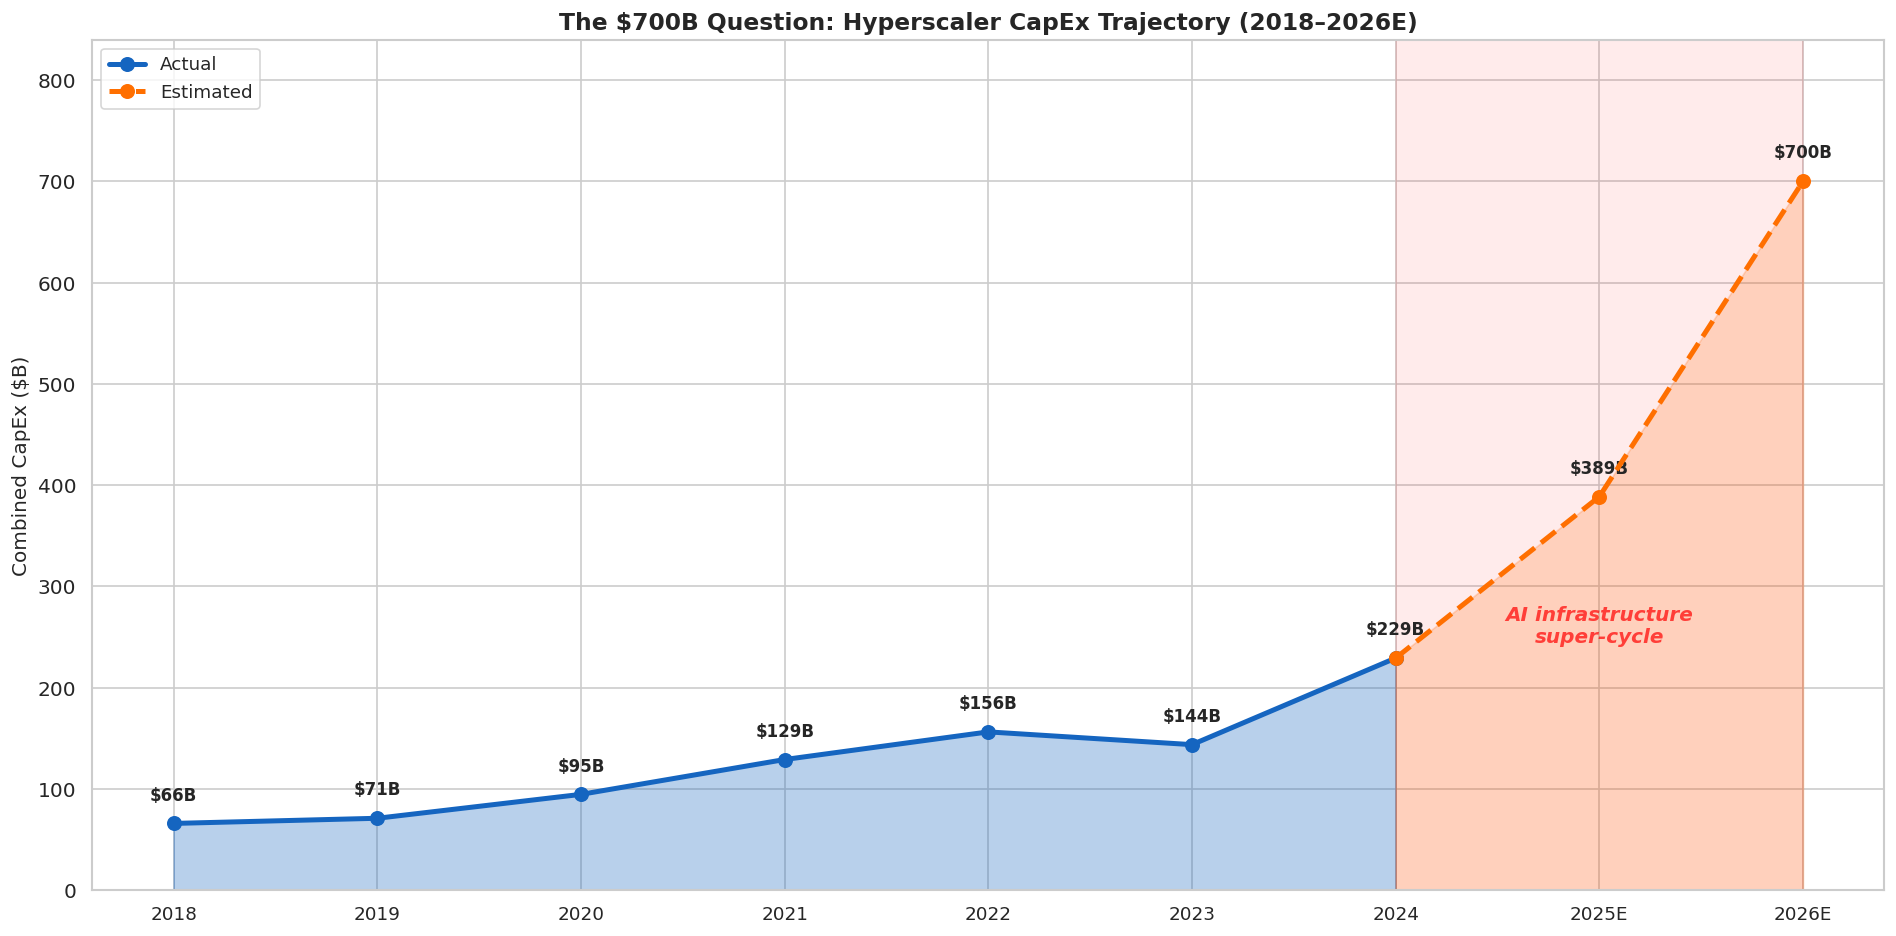


Analysis complete. All charts saved to data/ directory.


In [10]:
fig, ax = plt.subplots(figsize=(16, 8))

years_all = [str(c) for c in capex_annual.columns if c != 'Company']
totals_all = capex_annual[years_all].sum()

# Historical
hist_years = [y for y in years_all if 'E' not in y]
est_years = [y for y in years_all if 'E' in y]
hist_vals = [totals_all[y] for y in hist_years]
est_vals = [totals_all[y] for y in est_years]

ax.fill_between(range(len(hist_years)), hist_vals, alpha=0.3, color='#1565C0')
ax.plot(range(len(hist_years)), hist_vals, 'o-', color='#1565C0', linewidth=3,
        markersize=8, label='Actual', zorder=5)

est_x = list(range(len(hist_years)-1, len(hist_years) + len(est_years)))
est_full = [hist_vals[-1]] + est_vals
ax.fill_between(est_x, est_full, alpha=0.2, color='#FF6F00')
ax.plot(est_x, est_full, 'o--', color='#FF6F00', linewidth=3,
        markersize=8, label='Estimated', zorder=5)

all_x = list(range(len(years_all)))
all_vals = list(totals_all)
for xi, val in zip(all_x, all_vals):
    ax.annotate(f'${val:.0f}B', (xi, val), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(all_x)
ax.set_xticklabels(years_all, fontsize=11)
ax.set_ylabel('Combined CapEx ($B)', fontsize=12)
ax.set_title('The $700B Question: Hyperscaler CapEx Trajectory (2018–2026E)',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, max(all_vals) * 1.2)

ax.axvspan(years_all.index('2024'), len(years_all)-1, alpha=0.08, color='red')
ax.text(years_all.index('2025E'), max(all_vals) * 0.35,
        'AI infrastructure\nsuper-cycle', fontsize=12, ha='center',
        color='red', fontstyle='italic', fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.savefig('data/07_capex_trajectory_summary.png', bbox_inches='tight')
plt.show()

print('\nAnalysis complete. All charts saved to data/ directory.')